# Faithfulness and completeness, v2 — Wang et al. parity

Rebuild of `faithfulness_completeness.ipynb` after auditing the original IOI code
(`Easy-Transformer/easy_transformer/{ioi_circuit_extraction,completeness}.py`). v1 measured
something related to, but not the same as, Wang et al. (2023); v2 measures **their** quantities.

## What changed, and why

| | v1 | v2 | source |
|---|---|---|---|
| circuit element | attention head `(l, h)` | **`(l, h, position)`** | `ioi_circuit_extraction.py:205` — `RELEVANT_TOKENS` keeps each head at *one* token |
| MLPs | ablated under scope `all` | **never ablated**, only recorded | every call site passes `mlps_to_remove={}` |
| faithfulness | `(F(C) − F(∅)) / (F(M) − F(∅))` | **raw `F(C)`, plus the ratio `F(C)/F(M)`** | no normalisation exists in their code |
| `F(M\K)` | full model, `K` ablated at **all** positions | **`K` ablated only at `K`'s own positions** | `completeness.py:228` — `heads_to_remove=G_heads_to_remove` |
| incompleteness | `\|F(C\K) − F(M\K)\| / (F(M) − F(∅))` | **raw `\|F(C\K) − F(M\K)\|`** | `completeness.py:457` — `difference_eval` |
| `K` sampling | `\|K\| ~ U{1..\|C\|/2}` | **Bernoulli(½) per element**, + per-class `K`, + greedy adversarial | `completeness.py:625`, `:503` |
| granularity | node + edge | **node only** | they evaluate at head level; edges have no counterpart |
| search | `positional=False` | **`positional=True`** | their circuit is positional |

## Definitions actually computed

With `C` a set of `(head, position)` elements, all MLPs / embeddings / biases / LayerNorms left
intact, and every `(head, position)` **not** in `C` replaced by its mean over the ABC distribution:

$$F(C) \;=\; \mathbb{E}\big[\mathrm{logit}(\text{IO}) - \mathrm{logit}(\text{S})\big]_{\text{end}}$$

* **Faithfulness** — `F(C)` against `F(M)`. Reported raw and as the ratio `F(C)/F(M)`; that ratio is
  the percentage the paper quotes. Nothing is re-based on the empty circuit.
* **Incompleteness** — `|F(C\K) − F(M\K)|` in raw logit-difference units, where `F(M\K)` is the
  **full model with only `K` ablated, at `K`'s own positions**. Reported over (a) random `K`
  (Bernoulli ½), (b) the seven circuit classes, and (c) Wang's greedy adversarial search.

There is no `completeness = 1 − incompleteness` here: it is not their quantity, and with an
unnormalised gap it would not be on a `[0, 1]` scale anyway.

## Two deliberate deviations, stated up front

**One token layout.** A positional element is a raw index, so an index must mean the same thing in
every prompt. Both the search batch and the evaluation set are therefore drawn from a **single token
layout group** — same length, same `IO`/`S1`/`S2` offsets. Wang et al. instead use mixed templates
and take the ablation mean *within each template group* (`experiments.py:317`,
`ioi_dataset.py:757`); restricted to one group the two coincide exactly, so this is their per-group
computation with a single group, not a different estimator. It costs template diversity, nothing else.

**BOS.** Wang et al. run GPT-2 with `prepend_bos=False` (`ioi_dataset.py:684`). `ExperimentManager`
hardcodes `prepend_bos=True`, and search and evaluation must agree, so v2 keeps BOS. This shifts
`F(M)` and every ablation value relative to their numbers; it is the one protocol difference that
remains, and it is why `F(GT)/F(M)` here need not land exactly on their published figure.

**Dropped from v1:** edge granularity, and with it the "what the tree extension buys" panel. Wang et
al. evaluate at head level only. Positional nodes restore part of that resolution — a path set and a
tree that touch the same heads at *different positions* are now distinguishable — but not all of it.

In [1]:
import functools
import itertools
import json
import os
import random
import sys
import time
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

EXPERIMENTS_DIR = os.getcwd()                      # this notebook lives in experiments/
REPO_ROOT = os.path.dirname(EXPERIMENTS_DIR)
for p in (os.path.join(REPO_ROOT, "src"), REPO_ROOT, EXPERIMENTS_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)                      # `ipe` is used from src/, not pip-installed

SEARCH_CACHE_DIR = os.path.join(EXPERIMENTS_DIR, "detected_paths")
OUT_DIR = os.path.join(EXPERIMENTS_DIR, "faithfulness_completeness_v2")
os.makedirs(SEARCH_CACHE_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)                      # nothing here needs gradients
print(f"device: {DEVICE}   outputs -> {OUT_DIR}")

device: cuda   outputs -> /home/nicolobrunello/Documents/Projects/IPE-LatentCircuitIdentification/experiments/faithfulness_completeness_v2


## 1. Configuration

`base_min_contribution` is the only setting that costs real time. **Positional search is roughly 3x
the work of v1's non-positional search**: at a 15-token prompt a node expands to
`~12 x (1 MLP + 15x12 key/value + 12 query) ~= 2320` candidates instead of `~300`.

`PathMessagePatching` accepts a `max_time` budget; `TreeMessagePatching` does **not**, so the tree
sweep cannot be time-bounded — raise `base_min_contribution` if it runs long. Both searches use full
per-head, per-position expansion (`batch_heads=False`, `batch_positions=False`) because the tree has
no two-stage shortcut and the comparison has to stay apples-to-apples.

Set `QUICK = True` to exercise the whole pipeline in a few minutes at a coarse threshold.

In [2]:
@dataclass
class Config:
    # --- model / task -------------------------------------------------------
    model_name: str = "gpt2-small"
    target_length: int = 15            # tokenised prompt length the layout group is bucketed to

    # --- IPE search ---------------------------------------------------------
    search_batch: int = 5              # prompts the search itself scores on
    search_metric: str = "logit_difference"
    base_min_contribution: float = 0.05
    include_negative: bool = True      # admit by |contribution|
    positional: bool = True            # v2: positional search, as in Wang et al.
    batch_heads: bool = False          # full per-head expansion for BOTH searches (parity)
    batch_positions: bool = False      # full per-position expansion; the tree has no shortcut
    tree_joint_scoring: bool = True    # score tree candidates in the context of the tree so far
    path_max_time: float = None        # wall-clock budget for the path search (tree has none)

    # --- threshold sweep ----------------------------------------------------
    n_thresholds: int = 8
    max_threshold: float = 2.0

    # --- knockout evaluation ------------------------------------------------
    eval_size: int = 64                # IOI prompts the metric averages over
    eval_minibatch: int = 16
    ablation: str = "mean"             # "mean" = ABC mean-ablation (Wang et al.) | "resample"
    pool_scan: int = 6000              # dataset rows scanned when hunting for a layout group

    # --- completeness -------------------------------------------------------
    n_completeness_samples: int = 20   # random K, Bernoulli(1/2) per element (Wang et al.)
    seed: int = 0

    # --- greedy adversarial K (Wang et al. completeness.py:503) -------------
    greedy_runs: int = 3
    greedy_iters: int = 6
    greedy_samples: int = 8

CFG = Config()

QUICK = False
if QUICK:
    CFG.base_min_contribution = 0.5
    CFG.n_thresholds = 4
    CFG.eval_size, CFG.eval_minibatch = 16, 16
    CFG.n_completeness_samples = 5
    CFG.greedy_runs, CFG.greedy_iters, CFG.greedy_samples = 1, 3, 4

INCLUDE_RANDOM_BASELINE = True         # random circuit of matched size, as a sanity floor

random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)


def sweep_thresholds(cfg: Config) -> list[float]:
    """Log-spaced grid from the threshold the search ran at up to `max_threshold`."""
    lo, hi = cfg.base_min_contribution, cfg.max_threshold
    if hi <= lo:
        return [lo]
    return [float(t) for t in np.geomspace(lo, hi, cfg.n_thresholds)]


THRESHOLDS = sweep_thresholds(CFG)
print("thresholds:", [f"{t:.4g}" for t in THRESHOLDS])


def search_cache_file(cfg: Config, which: str, threshold: float = None) -> str:
    """Cache path for one search run.

    Keyed by `pos{positional}` so v2's positional runs never collide with v1's non-positional
    caches in the same directory. The tree is additionally keyed by threshold and scoring mode:
    under joint scoring a run at one threshold says nothing about another."""
    t = cfg.base_min_contribution if threshold is None else threshold
    scoring = "joint" if (which == "treesearch" and cfg.tree_joint_scoring) else "isolated"
    stem = (f"{which}_{scoring}_{cfg.model_name}_ioi_{cfg.search_metric}_th{t:g}"
            f"_bs{cfg.search_batch}_len{cfg.target_length}_pos{cfg.positional}"
            f"_heads{not cfg.batch_heads}.json")
    return os.path.join(SEARCH_CACHE_DIR, stem)


print(os.path.basename(search_cache_file(CFG, "pathsearch")))
print(f"tree scoring: {'joint (in context)' if CFG.tree_joint_scoring else 'isolated (per branch)'}"
      f"  ->  {len(THRESHOLDS) if CFG.tree_joint_scoring else 1} tree search(es)")

thresholds: ['0.05', '0.08469', '0.1435', '0.243', '0.4116', '0.6971', '1.181', '2']
pathsearch_isolated_gpt2-small_ioi_logit_difference_th0.05_bs5_len15_posTrue_headsTrue.json
tree scoring: joint (in context)  ->  8 tree search(es)


## 2. Data — one token layout group

A positional circuit element is a raw token index, so every prompt the search and the knockout see
must put `IO`, `S1`, `S2` and `end` at the *same* indices. We scan `mib-bench/ioi`, keep the samples
that tokenise to `target_length` with single-token IO/S and a length-matched ABC counterfactual,
bucket them by their **layout signature** `(IO, S1, S2, length)`, and take the most populous bucket.

Semantic positions follow Wang et al.'s `get_name_idxs` (`ioi_dataset.py:479`) exactly:

* `IO` — the single occurrence of the indirect-object name;
* `S1` — the **first** occurrence of the subject name, `S+1` its successor;
* `S2` — the **last** occurrence of the subject name;
* `end` — the final token (`" to"`), where the logit difference is read.

The search batch and the evaluation set are disjoint slices of that one bucket, so the ablation mean
is taken within a single template group — Wang's `mean_by_groups=True` with one group.

In [3]:
from transformer_lens import HookedTransformer


def load_model(cfg: Config) -> HookedTransformer:
    """GPT-2 with per-head outputs exposed at `blocks.L.attn.hook_result`.

    `center_unembed` shifts every logit by a per-position constant, which cancels in a logit
    *difference*, so it does not touch the metric. v2 does not need `use_split_qkv_input` or
    `use_hook_mlp_in`: the knockout is node-level and never rebuilds a destination's input."""
    model = HookedTransformer.from_pretrained(
        cfg.model_name, device=DEVICE, torch_dtype=torch.float32, center_unembed=True,
    )
    model.eval()
    model.cfg.use_attn_result = True
    return model


MODEL = load_model(CFG)
N_LAYERS, N_HEADS = MODEL.cfg.n_layers, MODEL.cfg.n_heads
print(f"{CFG.model_name}: {N_LAYERS} layers x {N_HEADS} heads")

Loaded pretrained model gpt2-small into HookedTransformer
gpt2-small: 12 layers x 12 heads


In [4]:
SEM_LABELS = ("IO", "S1", "S+1", "S2", "end")


def _single_token(model, text: str) -> bool:
    return len(model.to_str_tokens(text, prepend_bos=False)) == 1


def semantic_positions(model, prompt: str, io: str, subj: str) -> dict | None:
    """Wang et al.'s `get_name_idxs`, on a BOS-prefixed MIB prompt.

    Returns None when the prompt is not a well-formed IOI sentence for our purposes: the IO name
    must occur exactly once and the subject name exactly twice."""
    toks = model.to_tokens(prompt, prepend_bos=True)[0].tolist()
    io_tok, s_tok = model.to_single_token(f" {io}"), model.to_single_token(f" {subj}")
    if toks.count(io_tok) != 1 or toks.count(s_tok) != 2:
        return None
    s1 = toks.index(s_tok)
    return {
        "IO": toks.index(io_tok),
        "S1": s1,
        "S+1": s1 + 1,
        "S2": len(toks) - 1 - toks[::-1].index(s_tok),
        "end": len(toks) - 1,        # the " to" token: MIB prompts stop before the answer
    }


def load_layout_group(model, cfg: Config, n_needed: int, split: str = "train"):
    """The most populous token-layout bucket, with at least `n_needed` samples.

    A sample survives when it tokenises to `target_length`, its IO and S are single tokens, its ABC
    counterfactual tokenises to the same length (so the mean is position-aligned), and its semantic
    positions are recoverable. Bucketing is by `(IO, S1, S2, length)`."""
    from datasets import load_dataset

    ds = load_dataset("mib-bench/ioi", split=split)
    buckets, scanned = defaultdict(list), 0
    for sample in ds:
        scanned += 1
        if scanned > cfg.pool_scan:
            break
        if model.to_tokens(sample["prompt"], prepend_bos=True).shape[1] != cfg.target_length:
            continue
        io, subj = sample["metadata"]["indirect_object"], sample["metadata"]["subject"]
        if not (_single_token(model, f" {io}") and _single_token(model, f" {subj}")):
            continue
        abc = sample["abc_counterfactual"]["prompt"]
        if model.to_tokens(abc, prepend_bos=True).shape[1] != cfg.target_length:
            continue
        pos = semantic_positions(model, sample["prompt"], io, subj)
        if pos is None:
            continue
        buckets[(pos["IO"], pos["S1"], pos["S2"], cfg.target_length)].append((sample, pos))

    if not buckets:
        raise RuntimeError(f"no usable IOI samples of length {cfg.target_length} in {scanned} rows")
    sig, members = max(buckets.items(), key=lambda kv: len(kv[1]))
    print(f"scanned {scanned} rows -> {len(buckets)} layout groups; "
          f"largest {sig} has {len(members)} samples")
    for other, ms in sorted(buckets.items(), key=lambda kv: -len(kv[1]))[1:4]:
        print(f"    runner-up {other}: {len(ms)}")
    if len(members) < n_needed:
        raise RuntimeError(
            f"largest layout group has {len(members)} samples but {n_needed} are needed. "
            f"Raise CFG.pool_scan, lower CFG.eval_size, or try another CFG.target_length.")
    return [s for s, _ in members], members[0][1]


@dataclass
class SearchBatch:
    prompts: list[str]
    answers: list[str]
    cf_prompts: list[str]
    cf_answers: list[str]


@dataclass
class EvalSet:
    tokens: torch.Tensor        # [N, pos]  clean IOI prompts
    abc_tokens: torch.Tensor    # [N, pos]  ABC counterfactuals (the ablation distribution)
    io: torch.Tensor            # [N]       indirect-object token ids
    s: torch.Tensor             # [N]       subject token ids
    end: int                    # the position the logit difference is read at


def build_search_batch(samples: list[dict]) -> SearchBatch:
    cf_key = "s2_io_flip_counterfactual"
    prompts, answers, cf_prompts, cf_answers = [], [], [], []
    for s in samples:
        prompts.append(s["prompt"])
        answers.append(" " + s["metadata"]["indirect_object"])
        cf_prompts.append(s[cf_key]["prompt"])
        cf_answers.append(" " + s[cf_key]["choices"][s[cf_key]["answerKey"]])
    return SearchBatch(prompts, answers, cf_prompts, cf_answers)


def build_eval_set(model, samples: list[dict], pos: dict) -> EvalSet:
    return EvalSet(
        tokens=model.to_tokens([s["prompt"] for s in samples], prepend_bos=True),
        abc_tokens=model.to_tokens([s["abc_counterfactual"]["prompt"] for s in samples],
                                   prepend_bos=True),
        io=torch.tensor([model.to_single_token(" " + s["metadata"]["indirect_object"])
                         for s in samples], device=DEVICE),
        s=torch.tensor([model.to_single_token(" " + s["metadata"]["subject"])
                        for s in samples], device=DEVICE),
        end=pos["end"],
    )


group_samples, POS = load_layout_group(MODEL, CFG, CFG.search_batch + CFG.eval_size)
SEARCH = build_search_batch(group_samples[:CFG.search_batch])
EVAL = build_eval_set(MODEL, group_samples[CFG.search_batch:CFG.search_batch + CFG.eval_size], POS)

N_POS = EVAL.tokens.shape[1]
POSITION_LABEL = [""] * N_POS
POSITION_LABEL[0] = "BOS"
for lab in SEM_LABELS:
    POSITION_LABEL[POS[lab]] = lab


def pos_label(p: int) -> str:
    """`end`, `S2`, ... where the position is semantic; the bare index otherwise."""
    return POSITION_LABEL[p] or f"p{p}"


# Every prompt the search or the knockout touches must share the group's layout, or a raw position
# index means different things in different rows.
for _s in group_samples[:CFG.search_batch + CFG.eval_size]:
    assert semantic_positions(MODEL, _s["prompt"], _s["metadata"]["indirect_object"],
                              _s["metadata"]["subject"]) == POS, "layout group is not homogeneous"

# Wang et al. warn about exactly this (`double_s2`, ioi_dataset.py:501): if two semantic labels land
# on one token the ground-truth circuit silently loses elements, so refuse to continue.
assert len(set(POS.values())) == len(POS), f"semantic positions collide: {POS}"

_toks = MODEL.to_str_tokens(SEARCH.prompts[0], prepend_bos=True)
print("\nlayout: " + "  ".join(
    f"{i}:{_toks[i]!r}" + (f"={POSITION_LABEL[i]}" if POSITION_LABEL[i] else "")
    for i in range(N_POS)))
print(f"\nsemantic positions: {POS}")
print(f"search batch: {len(SEARCH.prompts)} prompts")
print(f"  clean  {SEARCH.prompts[0]!r} -> {SEARCH.answers[0]!r}")
print(f"  cfact  {SEARCH.cf_prompts[0]!r} -> {SEARCH.cf_answers[0]!r}")
print(f"eval set: {EVAL.tokens.shape[0]} prompts of {N_POS} tokens, metric read at pos {EVAL.end}")

scanned 6001 rows -> 2 layout groups; largest (4, 2, 10, 15) has 377 samples
    runner-up (4, 2, 9, 15): 64

layout: 0:'<|endoftext|>'=BOS  1:'After'  2:' Bob'=S1  3:' and'=S+1  4:' John'=IO  5:' went'  6:' to'  7:' the'  8:' depot'  9:','  10:' Bob'=S2  11:' gave'  12:' a'  13:' lamp'  14:' to'=end

semantic positions: {'IO': 4, 'S1': 2, 'S+1': 3, 'S2': 10, 'end': 14}
search batch: 5 prompts
  clean  'After Bob and John went to the depot, Bob gave a lamp to' -> ' John'
  cfact  'After Bob and John went to the depot, John gave a lamp to' -> ' Bob'
eval set: 64 prompts of 15 tokens, metric read at pos 14


## 3. Ground truth — Wang et al.'s circuit, positionally

The 26 heads in `experiments/tree_vs_path.py` are **exactly** the head set of `CIRCUIT` in
`ioi_circuit_extraction.py:168` (verified element-wise; our extra split of their single
`name mover` class into `Name Mover` + `Backup Name Mover` is cosmetic and follows the paper's
figure). What v1 was missing is `RELEVANT_TOKENS` (`:205`): each head is part of the circuit at
**one** token and mean-ablated at every other.

| class | heads | kept at |
|---|---|---|
| Name Mover, Backup Name Mover, Negative Name Mover, S-Inhibition | 17 | `end` |
| Induction, Duplicate Token | 7 | `S2` |
| Previous Token | 2 | `S+1` |

That is 26 `(head, position)` elements, against `26 x 15 = 390` for the non-positional reading. Both
are built: `ground truth` is theirs, `ground truth (all positions)` is the relaxation v1 scored — kept
because our searches are compared against it and it is the fairer target for a *non*-positional
circuit. IOI has no canonical MLP set and MLPs are never ablated, so they play no part here.

In [5]:
from tree_vs_path import IOI_CIRCUIT

# Wang et al.'s RELEVANT_TOKENS, expressed over our seven-class split of their six.
CLASS_POSITION = {
    "Name Mover": "end",
    "Backup Name Mover": "end",
    "Negative Name Mover": "end",
    "S-Inhibition": "end",
    "Induction": "S2",
    "Duplicate Token": "S2",
    "Previous Token": "S+1",
}
assert set(CLASS_POSITION) == set(IOI_CIRCUIT), "class/position map is out of sync with IOI_CIRCUIT"

GT_HEADS = {(l, h) for heads in IOI_CIRCUIT.values() for l, h in heads}
GT_CLASS_ELEMENTS = {
    group: frozenset(("attn", l, h, POS[CLASS_POSITION[group]]) for l, h in heads)
    for group, heads in IOI_CIRCUIT.items()
}
GT_ELEMENTS = frozenset(itertools.chain.from_iterable(GT_CLASS_ELEMENTS.values()))
GT_ELEMENTS_ALLPOS = frozenset(("attn", l, h, p) for l, h in GT_HEADS for p in range(N_POS))

ALL_ELEMENTS = frozenset(("attn", l, h, p)
                         for l in range(N_LAYERS) for h in range(N_HEADS) for p in range(N_POS))

assert len(GT_HEADS) == 26, len(GT_HEADS)
assert len(GT_ELEMENTS) == 26, "one element per head: the positional circuit must not collapse"
_by_pos = Counter(pos_label(e[3]) for e in GT_ELEMENTS)
assert _by_pos == {"end": 17, "S2": 7, "S+1": 2}, _by_pos     # Wang et al.'s RELEVANT_TOKENS split

print(f"{len(GT_HEADS)} ground-truth heads in {len(IOI_CIRCUIT)} classes -> "
      f"{len(GT_ELEMENTS)} (head, position) elements")
for group, heads in IOI_CIRCUIT.items():
    print(f"  {group:20s} @{CLASS_POSITION[group]:>4s} (pos {POS[CLASS_POSITION[group]]:2d})  "
          f"{sorted(heads)}")
print(f"\nrelaxation 'all positions': {len(GT_ELEMENTS_ALLPOS)} elements")
print(f"universe: {len(ALL_ELEMENTS)} = {N_LAYERS} x {N_HEADS} x {N_POS}")

26 ground-truth heads in 7 classes -> 26 (head, position) elements
  Name Mover           @ end (pos 14)  [(9, 6), (9, 9), (10, 0)]
  Negative Name Mover  @ end (pos 14)  [(10, 7), (11, 10)]
  Backup Name Mover    @ end (pos 14)  [(9, 0), (9, 7), (10, 1), (10, 2), (10, 6), (10, 10), (11, 2), (11, 9)]
  S-Inhibition         @ end (pos 14)  [(7, 3), (7, 9), (8, 6), (8, 10)]
  Induction            @  S2 (pos 10)  [(5, 5), (5, 8), (5, 9), (6, 9)]
  Duplicate Token      @  S2 (pos 10)  [(0, 1), (0, 10), (3, 0)]
  Previous Token       @ S+1 (pos  3)  [(2, 2), (4, 11)]

relaxation 'all positions': 390 elements
universe: 2160 = 12 x 12 x 15


## 4. Running the two searches (cached)

Both searches share one `ExperimentManager` — same batch, same metric, same patching, same per-head
**and per-position** expansion — so the only differences are path enumeration vs. trie construction
and the scoring rule. Each gets its own `clone_root`, since both mutate `root.children` in place.

`positional_search=True` makes `FINAL_Node.position = len - 1`, and every expansion candidate then
carries a query `position` (where the component writes) and, for the key/value branch, a
`keyvalue_position` (where it reads). The circuit element below is the **query** position: that is
what Wang et al.'s knockout replaces, since they overwrite `attn.hook_result` at the kept token.

> **Cost.** This is the only expensive cell, and it is ~3x v1. Expect hours on a GPU at
> `min_contribution = 0.05`. The path search honours `CFG.path_max_time`; `TreeMessagePatching` has
> no such parameter, so if the tree sweep is too slow the only lever is a higher threshold. Every run
> is skipped when its cache file exists.

In [6]:
from ipe.nodes import ATTN_Node, EMBED_Node, FINAL_Node, MLP_Node, Node
from ipe.experiment import ExperimentManager
from ipe.graph_search import PathMessagePatching, TreeMessagePatching, setup_tree_debug_log
from tree_vs_path import clone_root


def quiet_tree_logging() -> None:
    """The tree search emits one loguru record per scored candidate, and loguru's default sink is
    stderr — inside a notebook that is hundreds of thousands of lines. Drop the default sink and
    keep only the per-depth summaries, in a file."""
    from loguru import logger
    logger.remove()
    setup_tree_debug_log(os.path.join(OUT_DIR, "tree_search_debug.log"), level="INFO")


def node_to_dict(n: Node) -> dict:
    """Model-free description of one search node, keeping its branch contribution and position."""
    d = {"contribution": getattr(n, "contribution", None), "position": n.position}
    if isinstance(n, FINAL_Node):
        d["type"] = "final"
    elif isinstance(n, EMBED_Node):
        d["type"] = "embed"
    elif isinstance(n, MLP_Node):
        d.update(type="mlp", layer=n.layer)
    elif isinstance(n, ATTN_Node):
        d.update(type="attn", layer=n.layer, head=n.head, kv=n.keyvalue_position,
                 q=bool(n.patch_query), k=bool(n.patch_key), v=bool(n.patch_value))
    else:
        raise TypeError(f"unknown node type: {type(n)}")
    if d["contribution"] is not None:
        d["contribution"] = float(d["contribution"])
    return d


def paths_to_json(paths: list) -> list:
    return [{"contribution": float(score), "nodes": [node_to_dict(n) for n in path]}
            for score, path in paths]


def tree_to_json(node: Node) -> dict:
    return {"node": node_to_dict(node), "children": [tree_to_json(c) for c in node.children]}


def build_experiment(cfg: Config) -> ExperimentManager:
    """The activation caches, the metric (with its computed baseline) and the root node the searches
    share. The IOI inversion is the one `experiments/MIB/run_search.py` uses: clean and
    counterfactual prompts solve the same task with different names, so the roles are swapped and the
    counterfactual run becomes the base run."""
    return ExperimentManager(
        model=MODEL,
        prompts=SEARCH.cf_prompts,
        targets=SEARCH.cf_answers,
        cf_prompts=SEARCH.prompts,
        cf_targets=SEARCH.answers,
        algorithm="PathMessagePatching",
        search_strategy="Threshold",
        algorithm_params={"min_contribution": cfg.base_min_contribution,
                          "include_negative": cfg.include_negative},
        metric=cfg.search_metric,
        positional_search=cfg.positional,
        patch_type="counterfactual",
        patch_clean_into_cf=True,
    )


def run_path_search(cfg: Config, get_experiment, force: bool = False) -> dict:
    """One run at `base_min_contribution`; every higher threshold is derived from it by pruning."""
    out = search_cache_file(cfg, "pathsearch")
    if os.path.exists(out) and not force:
        print(f"cache hit: {os.path.basename(out)}")
        with open(out) as f:
            return json.load(f)

    experiment = get_experiment()
    t0 = time.time()
    paths = PathMessagePatching(
        MODEL, experiment.metric, clone_root(experiment.root),
        min_contribution=cfg.base_min_contribution,
        include_negative=cfg.include_negative,
        batch_heads=cfg.batch_heads,
        batch_positions=cfg.batch_positions,
        max_time=cfg.path_max_time,
    )
    seconds = time.time() - t0
    record = {"method": "path", "scoring": "isolated", "threshold": cfg.base_min_contribution,
              "config": asdict(cfg), "seconds": seconds, "paths": paths_to_json(paths)}
    with open(out, "w") as f:
        json.dump(record, f)
    print(f"path search @ {cfg.base_min_contribution:g}: {len(paths)} paths in {seconds:.0f}s")
    return record


def run_tree_search(cfg: Config, get_experiment, threshold: float, force: bool = False) -> dict:
    """One tree search at `threshold`, with the scoring rule `cfg.tree_joint_scoring` selects."""
    out = search_cache_file(cfg, "treesearch", threshold)
    if os.path.exists(out) and not force:
        print(f"cache hit: {os.path.basename(out)}")
        with open(out) as f:
            return json.load(f)

    experiment = get_experiment()
    quiet_tree_logging()
    t0 = time.time()
    root = TreeMessagePatching(
        MODEL, experiment.metric, clone_root(experiment.root),
        min_contribution=threshold,
        include_negative=cfg.include_negative,
        joint_scoring=cfg.tree_joint_scoring,
    )
    seconds = time.time() - t0
    record = {"method": "tree",
              "scoring": "joint" if cfg.tree_joint_scoring else "isolated",
              "threshold": threshold, "config": asdict(cfg), "seconds": seconds,
              "tree": tree_to_json(root)}
    with open(out, "w") as f:
        json.dump(record, f)
    print(f"tree search @ {threshold:g} ({record['scoring']}): {seconds:.0f}s")
    return record


def run_searches(cfg: Config, thresholds: list, force: bool = False):
    experiment = None

    def get_experiment():
        # Built lazily and once: it costs two forward passes plus the metric baseline, and is
        # unnecessary when every run is a cache hit.
        nonlocal experiment
        if experiment is None:
            experiment = build_experiment(cfg)
        return experiment

    path_record = run_path_search(cfg, get_experiment, force)
    if cfg.tree_joint_scoring:
        tree_records = {t: run_tree_search(cfg, get_experiment, t, force) for t in thresholds}
    else:
        shared = run_tree_search(cfg, get_experiment, cfg.base_min_contribution, force)
        tree_records = {t: shared for t in thresholds}
    return path_record, tree_records


PATH_REC, TREE_RECS = run_searches(CFG, THRESHOLDS)

tree_runs = {id(r): r for r in TREE_RECS.values()}      # distinct runs, not distinct thresholds
print(f"\npath search: {len(PATH_REC['paths'])} complete paths in {PATH_REC['seconds']:.0f}s")
print(f"tree search: {len(tree_runs)} run(s) totalling "
      f"{sum(r['seconds'] for r in tree_runs.values()):.0f}s")

100%|██████████| 4/4 [00:01<00:00,  2.14it/s]


path search @ 0.05: 83 paths in 1039s


100%|██████████| 7/7 [00:14<00:00,  2.02s/it]


tree search @ 0.05 (joint): 914s


100%|██████████| 1/1 [00:01<00:00,  1.52s/it]


...

tree search @ 0.697106 (joint): 41s


100%|██████████| 2/2 [00:01<00:00,  1.34it/s]


tree search @ 1.18077 (joint): 17s


100%|██████████| 1/1 [00:01<00:00,  1.03s/it]

tree search @ 2 (joint): 12s

path search: 83 complete paths in 1039s
tree search: 8 run(s) totalling 1882s


## 5. From a search result to a positional circuit

A circuit is a set of **`("attn", layer, head, position)`** elements — the objects the knockout
ablates — plus a *recorded but unevaluated* set of `("mlp", layer, position)` elements.

**The MLPs are kept, not discarded.** Our searches do discover MLPs; Wang et al.'s knockout simply
never ablates any MLP, so they cannot enter `F(C)` without leaving their protocol. Every circuit
therefore carries its `mlps` field, they are written out in section 11, and nothing else here reads
them.

`path_circuit` and `tree_circuit` take a threshold and prune to it. For the path search — and for the
tree under isolated scoring — that pruning *reproduces* the run at `t` exactly. For the tree under
joint scoring the record already is the run at `t`, so the prune is a no-op.

In [7]:
@dataclass(frozen=True)
class Circuit:
    name: str
    elements: frozenset             # ("attn", layer, head, position) — what the knockout ablates
    mlps: frozenset = frozenset()   # ("mlp", layer, position) — recorded, never ablated
    threshold: float = float("nan")
    n_paths: int = 0                # complete paths (path search) / root->leaf branches (tree)

    @property
    def heads(self) -> set:
        """Position-collapsed heads, for continuity with the v1 head-level agreement numbers."""
        return {(l, h) for _, l, h, _ in self.elements}

    @property
    def positions(self) -> set:
        return {p for e in self.elements for p in (e[3],)}


_SKIPPED = Counter()


def _collect(nd: dict, elems: set, mlps: set) -> None:
    """One serialised search node -> a circuit element, if it names one.

    `embed` and `final` are boundary nodes with nothing to ablate. A head-less ATTN node can only
    appear under `batch_heads=True` and a position-less node only under a non-positional search;
    both are counted and skipped rather than silently widened."""
    t = nd["type"]
    if t in ("embed", "final"):
        return
    if nd["position"] is None:
        _SKIPPED["position=None (non-positional node)"] += 1
        return
    if t == "mlp":
        mlps.add(("mlp", nd["layer"], nd["position"]))
    elif t == "attn":
        if nd["head"] is None:
            _SKIPPED["head=None (batched-head node)"] += 1
            return
        elems.add(("attn", nd["layer"], nd["head"], nd["position"]))


def path_circuit(rec: dict, t: float) -> Circuit:
    """Complete paths whose every node clears |contribution| >= t (the root carries none)."""
    elems, mlps, kept = set(), set(), 0
    for path in rec["paths"]:
        chain = path["nodes"]
        scores = [abs(n["contribution"]) for n in chain if n["contribution"] is not None]
        if scores and min(scores) < t:
            continue
        kept += 1
        for nd in chain:
            _collect(nd, elems, mlps)
    return Circuit(name="path", elements=frozenset(elems), mlps=frozenset(mlps),
                   threshold=t, n_paths=kept)


def tree_circuit(rec: dict, t: float) -> Circuit:
    """The tree with every node below the threshold — and its subtree — pruned away.

    A surviving node whose children were all pruned simply becomes a leaf, which is what the search
    at threshold `t` would itself have produced when none of its candidates cleared the bar."""
    elems, mlps, branches = set(), set(), 0

    def walk(entry: dict) -> None:
        nonlocal branches
        _collect(entry["node"], elems, mlps)
        kept_children = [c for c in entry["children"]
                         if c["node"]["contribution"] is None
                         or abs(c["node"]["contribution"]) >= t]
        if not kept_children:
            branches += 1
            return
        for child in kept_children:
            walk(child)

    walk(rec["tree"])
    return Circuit(name="tree", elements=frozenset(elems), mlps=frozenset(mlps),
                   threshold=t, n_paths=branches)


PATH_CIRCUITS = {t: path_circuit(PATH_REC, t) for t in THRESHOLDS}
# Under joint scoring TREE_RECS[t] is already the run at t, so the prune is a no-op; under isolated
# scoring it is the one base run and the prune is what reproduces the run at t.
TREE_CIRCUITS = {t: tree_circuit(TREE_RECS[t], t) for t in THRESHOLDS}

if _SKIPPED:
    print("WARNING: skipped search nodes that name no positional element:")
    for reason, n in _SKIPPED.items():
        print(f"  {n:6d}  {reason}")

print(f"{'t':>8}  {'path |C|':>9} {'heads':>6} {'MLPs':>5} {'paths':>7}   "
      f"{'tree |C|':>9} {'heads':>6} {'MLPs':>5} {'branches':>9}")
for t in THRESHOLDS:
    p, tr = PATH_CIRCUITS[t], TREE_CIRCUITS[t]
    print(f"{t:8.4g}  {len(p.elements):9d} {len(p.heads):6d} {len(p.mlps):5d} {p.n_paths:7d}   "
          f"{len(tr.elements):9d} {len(tr.heads):6d} {len(tr.mlps):5d} {tr.n_paths:9d}")

       t   path |C|  heads  MLPs   paths    tree |C|  heads  MLPs  branches
    0.05         18     18     5      83          39     38    10       548
 0.08469         14     14     1      33          29     29     6       279
  0.1435         11     11     1      13          22     22     3       154
   0.243          7      7     1       6          15     15     3       100
  0.4116          3      3     1       1          13     13     0        49
  0.6971          0      0     0       0          12     12     0        30
   1.181          0      0     0       0           6      6     0        13
       2          0      0     0       0           6      6     0         8


## 6. The knockout harness

This is `do_circuit_extraction` (`ioi_circuit_extraction.py:265`) rewritten against
`transformer_lens`. One hook per layer on `blocks.L.attn.hook_result`, whose activation has shape
`[batch, pos, head, d_head]`, and a boolean `keep[pos, head]` mask per layer:

```
x  <-  where(keep[pos, head], x, ablation[pos, head])
```

**What is never touched:** MLPs, embeddings, positional embeddings, attention and MLP biases,
LayerNorms. This is exactly their protocol — `mlps_to_remove={}` at all twelve call sites in the
Easy-Transformer repo — and it is why the metric stays on a sane scale for a head-only circuit.

Ablation values come from the **ABC counterfactual** run over the evaluation set, averaged per
position (`ablation="mean"`, Wang et al.) or taken per example (`ablation="resample"`). Because the
evaluation set is one layout group, that average *is* their per-template group mean.

Two mask builders, and the difference between them is the bug v1 had:

| | mask | meaning |
|---|---|---|
| `F(C)` | `keep[p,h] = (l,h,p) ∈ C` | everything outside the circuit is ablated |
| `F(M\K)` | `keep[p,h] = (l,h,p) ∉ K` | the **full model** with only `K` ablated, at `K`'s own positions |

v1 built `F(M\K)` by ablating each element of `K` at *every* position, which is a strictly harsher
perturbation and inflated every incompleteness number.

Both are memoised on the element set: the greedy search below re-evaluates the same circuits many
times and would otherwise dominate the runtime.

In [8]:
class Knockout:
    """Runs the model with a chosen set of (head, position) pairs mean-ablated."""

    def __init__(self, model: HookedTransformer, evalset: EvalSet, cfg: Config):
        self.model, self.eval, self.cfg = model, evalset, cfg
        self._abl = self._abl_from(evalset.abc_tokens)                 # [L, N, pos, head, d_head]
        if cfg.ablation == "mean":
            self._abl = self._abl.mean(1, keepdim=True)                # [L, 1, pos, head, d_head]
        elif cfg.ablation != "resample":
            raise ValueError(cfg.ablation)
        self._cache = {}
        self.n_forward = 0

    def _abl_from(self, tokens: torch.Tensor) -> torch.Tensor:
        names = {f"blocks.{l}.attn.hook_result" for l in range(N_LAYERS)}
        chunks = []
        for i in range(0, tokens.shape[0], self.cfg.eval_minibatch):
            _, cache = self.model.run_with_cache(
                tokens[i:i + self.cfg.eval_minibatch], names_filter=lambda n: n in names)
            chunks.append(torch.stack(
                [cache[f"blocks.{l}.attn.hook_result"] for l in range(N_LAYERS)], dim=0))
        return torch.cat(chunks, dim=1)

    # ------------------------------------------------------------------ masks
    @staticmethod
    def _blank(value: bool) -> list:
        return [torch.full((N_POS, N_HEADS), value, dtype=torch.bool, device=DEVICE)
                for _ in range(N_LAYERS)]

    @classmethod
    def keep_circuit(cls, elements) -> list:
        """Keep exactly the circuit's elements; ablate the rest.  ->  F(C)"""
        keep = cls._blank(False)
        for _, l, h, p in elements:
            keep[l][p, h] = True
        return keep

    @classmethod
    def keep_model_minus(cls, K) -> list:
        """Keep everything but K, ablated at K's own positions.  ->  F(M\\K), their cobble."""
        keep = cls._blank(True)
        for _, l, h, p in K:
            keep[l][p, h] = False
        return keep

    # ------------------------------------------------------------------ hooks
    @staticmethod
    def _h(x, hook, layer, keep, abl):
        # x: [batch, pos, head, d_head]; keep: [pos, head]; abl: [L, 1|batch, pos, head, d_head]
        return torch.where(keep[None, :, :, None], x, abl[layer])

    def _run(self, keep: list) -> float:
        n, mb = self.eval.tokens.shape[0], self.cfg.eval_minibatch
        # A layer whose mask is all-True needs no hook at all — this is what makes F(M\K) cheap.
        active = [l for l in range(N_LAYERS) if not bool(keep[l].all())]
        out = []
        for i in range(0, n, mb):
            sl = slice(i, min(i + mb, n))
            abl = self._abl if self._abl.shape[1] == 1 else self._abl[:, sl]
            hooks = [(f"blocks.{l}.attn.hook_result",
                      functools.partial(self._h, layer=l, keep=keep[l], abl=abl))
                     for l in active]
            logits = self.model.run_with_hooks(self.eval.tokens[sl], fwd_hooks=hooks)
            out.append(self._logit_diff(logits, sl))
            self.n_forward += 1
        return float(torch.cat(out).mean())

    def _logit_diff(self, logits: torch.Tensor, sl: slice) -> torch.Tensor:
        z = logits[:, self.eval.end, :]
        idx = torch.arange(z.shape[0], device=z.device)
        return z[idx, self.eval.io[sl]] - z[idx, self.eval.s[sl]]

    # ----------------------------------------------------------------- public
    def F(self, elements) -> float:
        """F(C): the circuit alone, everything outside it ablated."""
        key = ("circuit", frozenset(elements))
        if key not in self._cache:
            self._cache[key] = self._run(self.keep_circuit(elements))
        return self._cache[key]

    def F_model_minus(self, K) -> float:
        """F(M\\K): the full model with only K ablated, at K's own positions."""
        key = ("cobble", frozenset(K))
        if key not in self._cache:
            self._cache[key] = self._run(self.keep_model_minus(K))
        return self._cache[key]

    def clean(self) -> float:
        """F(M): no hooks at all."""
        n, mb = self.eval.tokens.shape[0], self.cfg.eval_minibatch
        out = []
        for i in range(0, n, mb):
            sl = slice(i, min(i + mb, n))
            out.append(self._logit_diff(self.model(self.eval.tokens[sl]), sl))
        return float(torch.cat(out).mean())


EV = Knockout(MODEL, EVAL, CFG)

### Sanity checks

The harness is only trustworthy if the degenerate circuits behave. Each of these must hold to
numerical precision:

1. the circuit of **all** `(head, position)` pairs reproduces the unhooked model — nothing is
   ablated, and since MLPs are never hooked this also confirms no MLP path is being disturbed;
2. `F(M\∅)` equals the unhooked model — the cobble mask agrees with the circuit mask at the top;
3. `F(∅) == F(M\everything)` — the two mask builders agree at the bottom, where every head is
   ablated at every position and only the MLPs, embeddings and biases survive;
4. `F(M\K)` for a small `K` is *not* `F(∅)` — a guard against the v1 bug, where `K` was ablated
   everywhere and `M\K` collapsed far below the full model.

In [9]:
F_MODEL = EV.clean()
checks = {
    "clean model (no hooks)": F_MODEL,
    "F(all elements)": EV.F(ALL_ELEMENTS),
    "F(M \\ {})": EV.F_model_minus(frozenset()),
    "F({}) = every head ablated": EV.F(frozenset()),
    "F(M \\ all elements)": EV.F_model_minus(ALL_ELEMENTS),
}

_rng = random.Random(CFG.seed)
_smallK = frozenset(_rng.sample(sorted(GT_ELEMENTS), 4))
checks["F(M \\ 4 GT elements)"] = EV.F_model_minus(_smallK)

for k, v in checks.items():
    print(f"  {k:34s} {v:+.6f}")

tol = 2e-3
assert abs(checks["F(all elements)"] - F_MODEL) < tol, "full circuit does not reproduce the model"
assert abs(checks["F(M \\ {})"] - F_MODEL) < tol, "empty cobble does not reproduce the model"
assert abs(checks["F({}) = every head ablated"]
           - checks["F(M \\ all elements)"]) < tol, "the two mask builders disagree at the bottom"
assert (checks["F(M \\ 4 GT elements)"]
        > checks["F({}) = every head ablated"] + 0.1), "M\\K collapsed: is K ablated everywhere?"

F_EMPTY = checks["F({}) = every head ablated"]
print(f"\nF(M) = {F_MODEL:+.4f}   F(empty) = {F_EMPTY:+.4f}")
print("F(empty) is a diagnostic only: it enters no formula in this notebook.")
print("all sanity checks passed")

  clean model (no hooks)             +3.119690
  F(all elements)                    +3.119690
  F(M \ {})                          +3.119690
  F({}) = every head ablated         +0.175928
  F(M \ all elements)                +0.175928
  F(M \ 4 GT elements)               +2.264172

F(M) = +3.1197   F(empty) = +0.1759
F(empty) is a diagnostic only: it enters no formula in this notebook.
all sanity checks passed


## 7. Faithfulness and completeness — Wang et al.'s definitions

**Faithfulness.** `F(C)` in raw logit-difference units, reported next to `F(M)` and as the ratio
`F(C)/F(M)`. That ratio is the percentage the paper quotes. A value above 1 means the circuit beats
the full model, which happens on IOI whenever the ablated remainder was net-negative for the metric.

**Incompleteness.** `|F(C\K) − F(M\K)|`, raw, over three families of `K`:

* **random** — each element included independently with probability ½
  (`completeness.py:625`: `torch.randint(0, 2, (len(all_nodes),))`);
* **by class** — the seven circuit classes, one at a time (`completeness.py:193`); this is the
  scatter that appears in the paper, and it is defined for the ground truth only, since the classes
  are a property of *their* circuit;
* **greedy** — their adversarial search for the `K` that maximises the gap
  (`completeness.py:503`), the number that actually bounds incompleteness from below.

`K = ∅` is included as a reference point: there `|F(C) − F(M)|` is just the faithfulness gap.

No quantity here is divided by anything. There is deliberately no `completeness = 1 − incompleteness`
column: it is not their metric, and an unnormalised gap does not live on `[0, 1]`.

In [10]:
@dataclass
class Scores:
    f: float                 # F(C), raw logit difference
    ratio: float             # F(C) / F(M) — the quantity the paper reports as a percentage
    gap_none: float          # |F(C) - F(M)|, the K = {} point
    incompl_mean: float      # mean |F(C\K) - F(M\K)| over random K, RAW units
    incompl_max: float       # worst sampled K
    n_samples: int


def random_subsets(elements, n: int, rng: random.Random):
    """Wang et al.'s random K: every element in or out independently with probability 1/2."""
    els = sorted(elements)
    for _ in range(n):
        yield frozenset(e for e in els if rng.random() < 0.5)


def incompleteness(ev: Knockout, circuit: Circuit, K) -> float:
    """|F(C\\K) - F(M\\K)| in raw logit-difference units."""
    K = frozenset(K)
    return abs(ev.F(circuit.elements - K) - ev.F_model_minus(K))


def score_circuit(ev: Knockout, circuit: Circuit, cfg: Config, n_samples: int = None) -> Scores:
    f = ev.F(circuit.elements)
    n_samples = cfg.n_completeness_samples if n_samples is None else n_samples
    gaps = []
    if circuit.elements and n_samples:
        rng = random.Random(cfg.seed)          # seeded, so every row sees a comparable draw
        gaps = [incompleteness(ev, circuit, K)
                for K in random_subsets(circuit.elements, n_samples, rng)]
    gaps = gaps or [float("nan")]
    return Scores(
        f=f,
        ratio=f / F_MODEL,
        gap_none=abs(f - F_MODEL),
        incompl_mean=float(np.mean(gaps)),
        incompl_max=float(np.max(gaps)),
        n_samples=len(gaps),
    )


def greedy_incompleteness(ev: Knockout, circuit: Circuit, cfg: Config, rng: random.Random):
    """Wang et al.'s greedy adversarial search for the K maximising |F(C\\K) - F(M\\K)|.

    Mirrors `new_greedy_search` (completeness.py:503): at each iteration sample `greedy_samples`
    elements still in C\\G, score each as a candidate addition to G, and take the best if it beats
    the running maximum. `greedy_runs` independent restarts; the reported value is the best over all
    of them. Every evaluation goes through the memoised knockout, so restarts are cheap."""
    els = sorted(circuit.elements)
    if not els:
        return float("nan"), frozenset()
    best_value, best_set = incompleteness(ev, circuit, frozenset()), frozenset()
    for _ in range(cfg.greedy_runs):
        remaining, G, running = list(els), [], best_value
        for _ in range(cfg.greedy_iters):
            if not remaining:
                break
            to_test = rng.sample(remaining, min(cfg.greedy_samples, len(remaining)))
            scored = [(incompleteness(ev, circuit, frozenset(G + [n])), n) for n in to_test]
            value, node = max(scored, key=lambda vn: vn[0])
            if value > running:
                running = value
                remaining.remove(node)
                G.append(node)
        if running > best_value:
            best_value, best_set = running, frozenset(G)
    return best_value, best_set


def agreement(circuit: Circuit) -> dict:
    """Overlap with the ground truth, at both resolutions.

    `element_*` scores the positional claim against Wang et al.'s 26 (head, position) nodes;
    `head_*` collapses positions away and reproduces the v1 head-level numbers, so the two notebooks
    stay comparable."""
    out = {}
    for tag, found, truth in (("element", set(circuit.elements), set(GT_ELEMENTS)),
                              ("head", circuit.heads, GT_HEADS)):
        tp = len(found & truth)
        out[f"{tag}_precision"] = tp / len(found) if found else 0.0
        out[f"{tag}_recall"] = tp / len(truth)
        out[f"{tag}_f1"] = 2 * tp / (len(found) + len(truth)) if (found or truth) else 0.0
    return out


def random_circuit_like(circuit: Circuit, rng: random.Random) -> Circuit:
    """A size-matched random circuit — the floor any real discovery method has to clear."""
    n = min(len(circuit.elements), len(ALL_ELEMENTS))
    return Circuit(name="random", elements=frozenset(rng.sample(sorted(ALL_ELEMENTS), n)),
                   threshold=circuit.threshold)


GT_CIRCUIT = Circuit(name="ground truth", elements=GT_ELEMENTS)
GT_ALLPOS_CIRCUIT = Circuit(name="ground truth (all positions)", elements=GT_ELEMENTS_ALLPOS)
FULL_CIRCUIT = Circuit(name="full model", elements=ALL_ELEMENTS)
EMPTY_CIRCUIT = Circuit(name="empty", elements=frozenset())

print(f"F(M)  = {F_MODEL:+.4f}")
for c in (GT_CIRCUIT, GT_ALLPOS_CIRCUIT):
    f = EV.F(c.elements)
    print(f"F({c.name}) = {f:+.4f}   ratio F(C)/F(M) = {f / F_MODEL:6.1%}   |C| = {len(c.elements)}")

F(M)  = +3.1197
F(ground truth) = +4.5331   ratio F(C)/F(M) = 145.3%   |C| = 26
F(ground truth (all positions)) = +4.2447   ratio F(C)/F(M) = 136.1%   |C| = 390


## 8. The sweep

One row per `(method, threshold)`, plus the reference rows: the ground truth (positional and the
all-positions relaxation), the full model, the empty circuit, and a size-matched random circuit at
every threshold.

In [11]:
def row_for(circuit: Circuit, method: str, cfg: Config) -> dict:
    s = score_circuit(EV, circuit, cfg)
    return {
        "method": method,
        "threshold": circuit.threshold,
        "n_elements": len(circuit.elements),
        "n_heads": len(circuit.heads),
        "n_positions": len(circuit.positions),
        "n_mlps": len(circuit.mlps),
        "n_paths": circuit.n_paths,
        "F": s.f,
        "ratio": s.ratio,
        "gap_none": s.gap_none,
        "incompl_mean": s.incompl_mean,
        "incompl_max": s.incompl_max,
        **agreement(circuit),
    }


rows = []
rng = random.Random(CFG.seed)
work = [(m, t) for m in ("path", "tree") for t in THRESHOLDS]

for method, t in tqdm(work, desc="sweep"):
    circuit = (PATH_CIRCUITS if method == "path" else TREE_CIRCUITS)[t]
    rows.append(row_for(circuit, method, CFG))
    if INCLUDE_RANDOM_BASELINE and method == "tree":
        rows.append(row_for(random_circuit_like(circuit, rng), "random", CFG))

for circuit, label in ((GT_CIRCUIT, "ground truth"),
                       (GT_ALLPOS_CIRCUIT, "ground truth (all positions)"),
                       # With C = M every sampled K gives F(C\K) = F(M\K) exactly, so the full
                       # model's incompleteness has to come out at 0.000 — the last check that the
                       # sampler and the two mask builders agree.
                       (FULL_CIRCUIT, "full model"),
                       (EMPTY_CIRCUIT, "empty")):
    rows.append(row_for(circuit, label, CFG))

df = pd.DataFrame(rows)
df.to_csv(os.path.join(OUT_DIR, "faithfulness_completeness_v2.csv"), index=False)
print(f"{len(df)} rows, {EV.n_forward} forward passes "
      f"({len(EV._cache)} distinct circuits evaluated)")
print(f"-> {os.path.join(OUT_DIR, 'faithfulness_completeness_v2.csv')}")

_full = df[df.method == "full model"].iloc[0]
assert abs(_full.incompl_mean) < 2e-3, f"full model incompleteness should be 0: {_full.incompl_mean}"
df.head()

sweep:   0%|          | 0/16 [00:00<?, ?it/s]

28 rows, 3532 forward passes (883 distinct circuits evaluated)
-> /home/nicolobrunello/Documents/Projects/IPE-LatentCircuitIdentification/experiments/faithfulness_completeness_v2/faithfulness_completeness_v2.csv


,method,threshold,n_elements,n_heads,n_positions,n_mlps,n_paths,F,ratio,gap_none,incompl_mean,incompl_max,element_precision,element_recall,element_f1,head_precision,head_recall,head_f1
0,path,0.050000,18,18,2,5,83,2.160247,0.692456,0.959443,0.609506,2.252269,0.888889,0.615385,0.727273,0.888889,0.615385,0.727273
1,path,0.084691,14,14,2,1,33,0.806733,0.258594,2.312957,1.194558,6.219449,1.000000,0.538462,0.700000,1.000000,0.538462,0.700000
2,path,0.143450,11,11,2,1,13,0.345638,0.110792,2.774052,1.241918,3.456890,1.000000,0.423077,0.594595,1.000000,0.423077,0.594595
3,path,0.242978,7,7,2,1,6,-1.615627,-0.517881,4.735317,2.461886,4.642527,1.000000,0.269231,0.424242,1.000000,0.269231,0.424242
4,path,0.411560,3,3,2,1,1,-1.057795,-0.339070,4.177485,2.409185,4.177485,1.000000,0.115385,0.206897,1.000000,0.115385,0.206897


## 9. The comparison tables

`|C|` is the number of `(head, position)` elements, `heads` the distinct heads behind them. `F(C)` and
the incompleteness columns are raw logit differences; `F/F(M)` is the ratio the paper reports.
`elem F1` scores the positional claim against Wang et al.'s 26 elements, `head F1` collapses positions
away and is directly comparable to v1.

Read `F/F(M)` against `100%` and the incompleteness columns against `0`.

In [12]:
SWEEP_COLS = [
    ("n_elements", "|C|"),
    ("n_heads", "heads"),
    ("n_mlps", "MLPs"),
    ("n_paths", "paths"),
    ("F", "F(C)"),
    ("ratio", "F/F(M)"),
    ("incompl_mean", "incompl"),
    ("incompl_max", "worst K"),
    ("element_f1", "elem F1"),
    ("head_f1", "head F1"),
]
INT_COLS = {"|C|", "heads", "MLPs", "paths"}
PCT_COLS = {"F/F(M)"}
SWEPT_METHODS = ("path", "tree", "random")
SWEEP_LABEL = "min_contribution"


def show(table: pd.DataFrame) -> pd.DataFrame:
    """Counts as integers, ratios as percentages, everything else to three decimals, NaN blank."""
    def label(c):
        return c[-1] if isinstance(c, tuple) else c
    out = table.copy()
    for c in out.columns:
        lab = label(c)
        fmt = "{:.0f}" if lab in INT_COLS else ("{:.1%}" if lab in PCT_COLS else "{:.3f}")
        out[c] = out[c].map(lambda v, f=fmt: "" if pd.isna(v) else f.format(v))
    return out


def comparison_table(df: pd.DataFrame) -> pd.DataFrame:
    sub = df[df.method.isin(SWEPT_METHODS)]
    blocks = []
    for method in SWEPT_METHODS:
        d = sub[sub.method == method].set_index("threshold").sort_index()
        if d.empty:
            continue
        d = d[[c for c, _ in SWEEP_COLS]].rename(columns=dict(SWEEP_COLS))
        d.columns = pd.MultiIndex.from_product([[method], d.columns], names=["", ""])
        blocks.append(d)
    out = pd.concat(blocks, axis=1)
    out.index = [f"{t:.4g}" for t in out.index]
    out.index.name = SWEEP_LABEL
    return out


def reference_table(df: pd.DataFrame) -> pd.DataFrame:
    sub = df[~df.method.isin(SWEPT_METHODS)]
    cols = [(c, lab) for c, lab in SWEEP_COLS if c != "n_paths"]
    out = sub.set_index("method")[[c for c, _ in cols]].rename(columns=dict(cols))
    out.index.name = "reference"
    return out


TABLE, REFERENCE = comparison_table(df), reference_table(df)
scoring = "joint" if CFG.tree_joint_scoring else "isolated"
print("=" * 118)
print("GPT-2 small / IOI — positional node knockout, ABC mean-ablation, MLPs intact")
print(f"tree scoring = {scoring}   |   F(M) = {F_MODEL:+.4f}   |   raw logit differences")
print("=" * 118)
print(show(TABLE).to_string())
print("\nreference circuits:")
print(show(REFERENCE).to_string())

for name, tbl in (("comparison", TABLE), ("reference", REFERENCE)):
    with open(os.path.join(OUT_DIR, f"{name}_v2.tex"), "w") as f:
        f.write(show(tbl).to_latex())
print(f"\nLaTeX -> {OUT_DIR}/comparison_v2.tex, reference_v2.tex")

GPT-2 small / IOI — positional node knockout, ABC mean-ablation, MLPs intact
tree scoring = joint   |   F(M) = +3.1197   |   raw logit differences
                 path                                                                  tree                                                                random                                                               
                  |C| heads MLPs paths    F(C)  F/F(M) incompl worst K elem F1 head F1  |C| heads MLPs paths   F(C) F/F(M) incompl worst K elem F1 head F1    |C| heads MLPs paths   F(C) F/F(M) incompl worst K elem F1 head F1
min_contribution                                                                                                                                                                                                                
0.05               18    18    5    83   2.160   69.2%   0.610   2.252   0.727   0.727   39    38   10   548  0.569  18.2%   1.120   2.926   0.615   0.625     39    35    0     0

## 10. Incompleteness by circuit class, and the greedy adversarial `K`

Two things the random draw cannot give you.

**By class.** Wang et al.'s headline completeness figure removes one *circuit class* at a time and
plots `F(C\K)` against `F(M\K)`; a complete circuit sits on the diagonal. The classes are a property
of their circuit, so this is defined for the ground truth only.

**Greedy.** Their adversarial search for the worst `K` (`completeness.py:503`). This is the number
that actually bounds incompleteness — a mean over random subsets understates it badly, because most
random `K` are uninformative. It is run only on the circuits named in `GREEDY_ON`, since each run
costs `greedy_runs x greedy_iters x greedy_samples` circuit pairs.

In [13]:
# The matched-budget circuit from each search: the threshold whose |C| is closest to the ground
# truth's 26 elements. A neutral criterion — it does not look at any score.
def matched_budget(circuits: dict) -> float:
    return min(circuits, key=lambda t: abs(len(circuits[t].elements) - len(GT_ELEMENTS)))


T_PATH, T_TREE = matched_budget(PATH_CIRCUITS), matched_budget(TREE_CIRCUITS)
GREEDY_ON = {
    "ground truth": GT_CIRCUIT,
    f"path @ {T_PATH:.3g}": PATH_CIRCUITS[T_PATH],
    f"tree @ {T_TREE:.3g}": TREE_CIRCUITS[T_TREE],
}
print(f"matched budget vs |GT| = {len(GT_ELEMENTS)}: "
      f"path t={T_PATH:.4g} (|C|={len(PATH_CIRCUITS[T_PATH].elements)}), "
      f"tree t={T_TREE:.4g} (|C|={len(TREE_CIRCUITS[T_TREE].elements)})")

# --- by class (ground truth only) --------------------------------------------------------------
class_rows = []
for group, elements in GT_CLASS_ELEMENTS.items():
    class_rows.append({
        "K": group,
        "|K|": len(elements),
        "F(C\\K)": EV.F(GT_ELEMENTS - elements),
        "F(M\\K)": EV.F_model_minus(elements),
    })
class_rows.append({"K": "none", "|K|": 0,
                   "F(C\\K)": EV.F(GT_ELEMENTS), "F(M\\K)": F_MODEL})
df_class = pd.DataFrame(class_rows)
df_class["gap"] = (df_class["F(C\\K)"] - df_class["F(M\\K)"]).abs()
df_class = df_class.sort_values("gap", ascending=False)
df_class.to_csv(os.path.join(OUT_DIR, "incompleteness_by_class_v2.csv"), index=False)

print("\nIncompleteness by circuit class — ground truth (completeness.py:193)")
print("gap = |F(C\\K) - F(M\\K)|")
print(df_class.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

# --- greedy adversarial K ----------------------------------------------------------------------
greedy_rows = []
grng = random.Random(CFG.seed)
for label, circuit in tqdm(GREEDY_ON.items(), desc="greedy"):
    value, K = greedy_incompleteness(EV, circuit, CFG, grng)
    greedy_rows.append({
        "circuit": label,
        "|C|": len(circuit.elements),
        "greedy incompl": value,
        "|K*|": len(K),
        "K*": ", ".join(f"a{l}.h{h}@{pos_label(p)}" for _, l, h, p in sorted(K)) or "(none)",
    })
df_greedy = pd.DataFrame(greedy_rows)
df_greedy.to_csv(os.path.join(OUT_DIR, "incompleteness_greedy_v2.csv"), index=False)

print(f"\nGreedy adversarial K "
      f"({CFG.greedy_runs} runs x {CFG.greedy_iters} iters x {CFG.greedy_samples} samples)")
print(df_greedy.drop(columns="K*").to_string(index=False, float_format=lambda v: f"{v:.4f}"))
for r in greedy_rows:
    print(f"  {r['circuit']:>22s}  K* = {r['K*']}")
print(f"\n{EV.n_forward} forward passes so far, {len(EV._cache)} distinct circuits cached")

matched budget vs |GT| = 26: path t=0.05 (|C|=18), tree t=0.08469 (|C|=29)

Incompleteness by circuit class — ground truth (completeness.py:193)
gap = |F(C\K) - F(M\K)|
                  K  |K|  F(C\K)  F(M\K)     gap
Negative Name Mover    2 +8.2394 +6.7283 +1.5111
               none    0 +4.5331 +3.1197 +1.4135
     Previous Token    2 +1.7316 +2.8718 +1.1402
  Backup Name Mover    8 +3.8713 +2.9313 +0.9401
         Name Mover    3 +3.9410 +3.0679 +0.8731
       S-Inhibition    4 +0.7652 +0.1979 +0.5672
          Induction    4 +1.2631 +0.7775 +0.4856
    Duplicate Token    3 +2.1707 +1.7038 +0.4668


greedy:   0%|          | 0/3 [00:00<?, ?it/s]


Greedy adversarial K (3 runs x 6 iters x 8 samples)
      circuit  |C|  greedy incompl  |K*|
 ground truth   26          2.0568     4
  path @ 0.05   18          3.5470     4
tree @ 0.0847   29          7.8883     6
            ground truth  K* = a7.h3@end, a9.h7@end, a11.h2@end, a11.h10@end
             path @ 0.05  K* = a0.h1@S2, a9.h6@end, a10.h7@end, a11.h2@end
           tree @ 0.0847  K* = a3.h0@S2, a9.h4@end, a10.h7@end, a11.h2@end, a11.h6@end, a11.h10@end

4896 forward passes so far, 1224 distinct circuits cached


## 11. The discovered MLPs

Never ablated, never scored — Wang et al.'s protocol has no place for them — but recorded at every
threshold for both searches and written out here, since our searches *do* find them and the next
experiment will want them.

In [14]:
mlp_records = []
for method, circuits in (("path", PATH_CIRCUITS), ("tree", TREE_CIRCUITS)):
    for t, circuit in circuits.items():
        for _, layer, p in sorted(circuit.mlps):
            mlp_records.append({"method": method, "threshold": t,
                                "layer": layer, "position": p, "position_label": pos_label(p)})

df_mlp = pd.DataFrame(mlp_records, columns=["method", "threshold", "layer", "position",
                                            "position_label"])
df_mlp.to_csv(os.path.join(OUT_DIR, "discovered_mlps_v2.csv"), index=False)
print(f"{len(df_mlp)} (method, threshold, MLP, position) records "
      f"-> {os.path.join(OUT_DIR, 'discovered_mlps_v2.csv')}")

if len(df_mlp):
    base = df_mlp[df_mlp.threshold == min(THRESHOLDS)]
    print(f"\nAt the base threshold {min(THRESHOLDS):.4g}, MLP layers by position:")
    for method in ("path", "tree"):
        sub = base[base.method == method]
        by_pos = defaultdict(list)
        for _, r in sub.iterrows():
            by_pos[r.position_label].append(r.layer)
        cells = "   ".join(f"{lab}: {sorted(set(ls))}" for lab, ls in sorted(by_pos.items()))
        print(f"  {method:>5s}  {cells or '(none)'}")
else:
    print("no MLPs were admitted at any threshold")

31 (method, threshold, MLP, position) records -> /home/nicolobrunello/Documents/Projects/IPE-LatentCircuitIdentification/experiments/faithfulness_completeness_v2/discovered_mlps_v2.csv

At the base threshold 0.05, MLP layers by position:
   path  S2: [0, 1, 3, 4]   end: [10]
   tree  S2: [0, 1, 5, 6, 7]   end: [8, 9, 10, 11]   p11: [10]


## 12. Plots

Four views of the sweep, then Wang et al.'s completeness scatter.

Colour carries the search and is never the only cue — every series also has its own marker and dash
pattern, so the figures survive greyscale printing and colour-vision deficiency. The palette is
Okabe–Ito, a published CVD-safe qualitative set, assigned in fixed order and never cycled.

saved /home/nicolobrunello/Documents/Projects/IPE-LatentCircuitIdentification/experiments/faithfulness_completeness_v2/tree_vs_path_positional.png


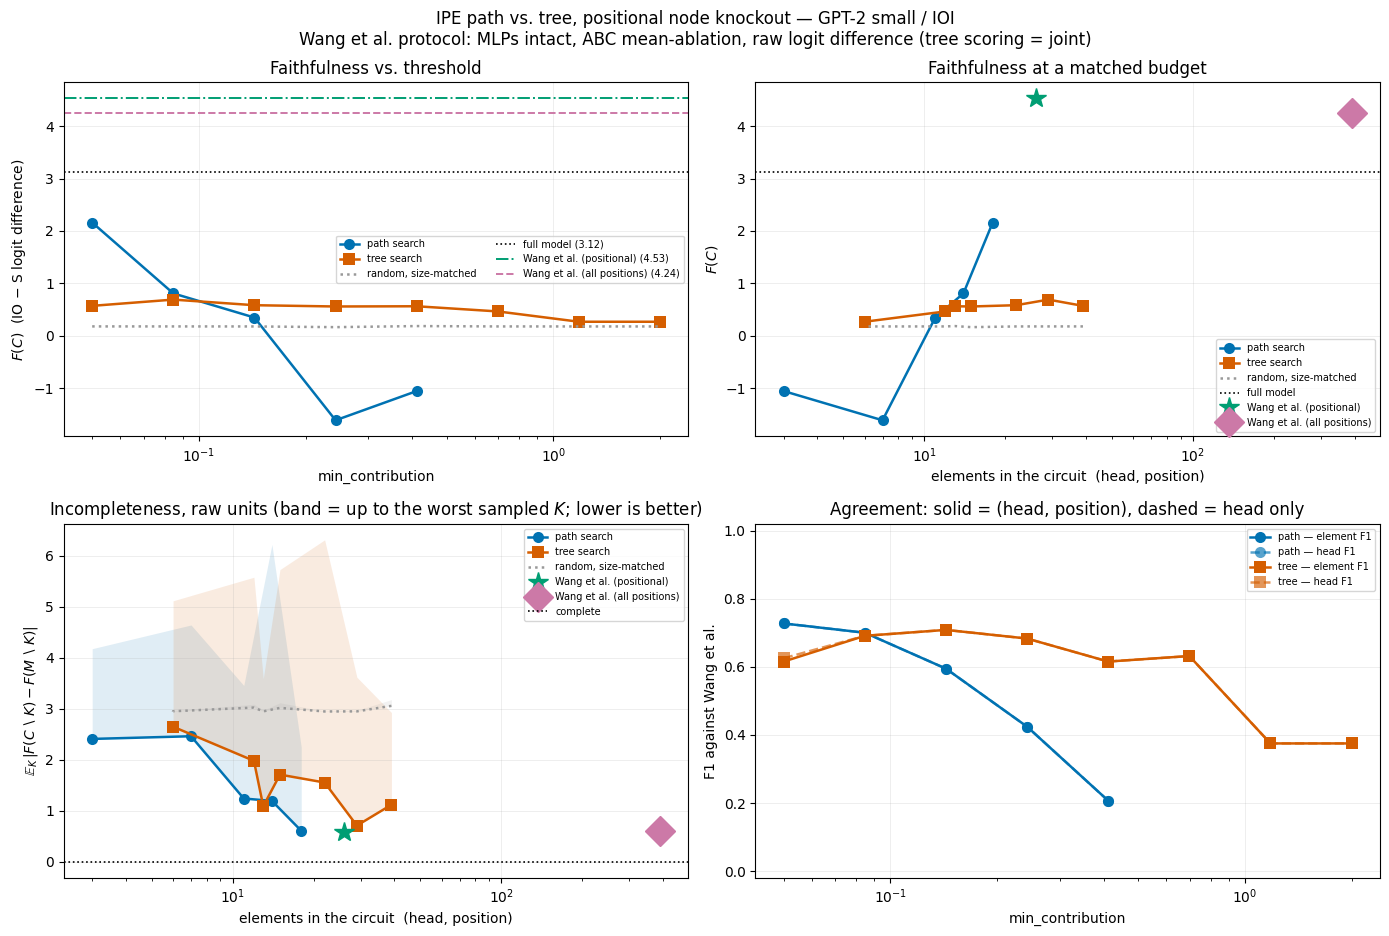

In [15]:
# Okabe-Ito, assigned in fixed order. Identity is carried by colour AND marker AND dash, so no
# series is distinguished by hue alone.
STYLE = {
    "path":   dict(color="#0072B2", marker="o", ls="-",  label="path search"),
    "tree":   dict(color="#D55E00", marker="s", ls="-",  label="tree search"),
    "random": dict(color="#999999", marker="x", ls=":",  label="random, size-matched"),
}
REF_STYLE = {
    "ground truth":                 dict(color="#009E73", marker="*", ls="-.",
                                         label="Wang et al. (positional)"),
    "ground truth (all positions)": dict(color="#CC79A7", marker="D", ls="--",
                                         label="Wang et al. (all positions)"),
}
GRID = dict(alpha=0.25, lw=0.6)


def sweep_rows(frame, method):
    """Thresholds ascending, with empty circuits dropped — they carry no information and cannot be
    placed on a log axis."""
    return frame[(frame.method == method) & (frame.n_elements > 0)].sort_values("threshold")


def ref_value(frame, method, column):
    r = frame[frame.method == method]
    return r.iloc[0][column] if len(r) else float("nan")


def line(ax, x, y, spec, **kw):
    st = dict(spec)
    st.update(kw)
    ax.plot(x, y, lw=1.8, ms=8, markeredgewidth=0, **st)


fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
fig.suptitle(
    "IPE path vs. tree, positional node knockout — GPT-2 small / IOI\n"
    "Wang et al. protocol: MLPs intact, ABC mean-ablation, raw logit difference "
    f"(tree scoring = {'joint' if CFG.tree_joint_scoring else 'isolated'})", fontsize=12)

# (a) F(C) vs threshold ---------------------------------------------------------------------------
ax = axes[0, 0]
for method in ("path", "tree", "random"):
    sub = sweep_rows(df, method)
    if len(sub):
        line(ax, sub.threshold, sub.F, STYLE[method])
ax.axhline(F_MODEL, color="black", lw=1.2, ls=":", label=f"full model ({F_MODEL:.2f})")
for name, spec in REF_STYLE.items():
    v = ref_value(df, name, "F")
    if not np.isnan(v):
        ax.axhline(v, color=spec["color"], lw=1.4, ls=spec["ls"],
                   label=f"{spec['label']} ({v:.2f})")
ax.set_xscale("log")
ax.set_xlabel(SWEEP_LABEL)
ax.set_ylabel(r"$F(C)$  (IO $-$ S logit difference)")
ax.set_title("Faithfulness vs. threshold")
ax.grid(**GRID)
ax.legend(fontsize=7, ncol=2)

# (b) F(C) vs |C| ---------------------------------------------------------------------------------
ax = axes[0, 1]
for method in ("path", "tree", "random"):
    sub = sweep_rows(df, method)
    if len(sub):
        line(ax, sub.n_elements, sub.F, STYLE[method])
ax.axhline(F_MODEL, color="black", lw=1.2, ls=":", label="full model")
for name, spec in REF_STYLE.items():
    r = df[df.method == name]
    if len(r):
        ax.plot([r.iloc[0].n_elements], [r.iloc[0].F], marker=spec["marker"], ms=15, ls="none",
                color=spec["color"], label=spec["label"])
ax.set_xscale("log")
ax.set_xlabel("elements in the circuit  (head, position)")
ax.set_ylabel(r"$F(C)$")
ax.set_title("Faithfulness at a matched budget")
ax.grid(**GRID)
ax.legend(fontsize=7)

# (c) incompleteness vs |C| -----------------------------------------------------------------------
ax = axes[1, 0]
for method in ("path", "tree", "random"):
    sub = sweep_rows(df, method)
    if not len(sub):
        continue
    line(ax, sub.n_elements, sub.incompl_mean, STYLE[method])
    ax.fill_between(sub.n_elements, sub.incompl_mean, sub.incompl_max,
                    color=STYLE[method]["color"], alpha=0.12, lw=0)
for name, spec in REF_STYLE.items():
    r = df[df.method == name]
    if len(r):
        ax.plot([r.iloc[0].n_elements], [r.iloc[0].incompl_mean], marker=spec["marker"], ms=15,
                ls="none", color=spec["color"], label=spec["label"])
ax.axhline(0.0, color="black", lw=1.2, ls=":", label="complete")
ax.set_xscale("log")
ax.set_xlabel("elements in the circuit  (head, position)")
ax.set_ylabel(r"$\mathbb{E}_K\,|F(C\setminus K) - F(M\setminus K)|$")
ax.set_title("Incompleteness, raw units (band = up to the worst sampled $K$; lower is better)")
ax.grid(**GRID)
ax.legend(fontsize=7)

# (d) agreement with the ground truth --------------------------------------------------------------
ax = axes[1, 1]
for method in ("path", "tree"):
    sub = sweep_rows(df, method)
    if not len(sub):
        continue
    c = STYLE[method]["color"]
    line(ax, sub.threshold, sub.element_f1,
         dict(color=c, marker=STYLE[method]["marker"], ls="-"),
         label=f"{method} — element F1")
    line(ax, sub.threshold, sub.head_f1,
         dict(color=c, marker=STYLE[method]["marker"], ls="--"),
         label=f"{method} — head F1", alpha=0.65)
ax.set_xscale("log")
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel(SWEEP_LABEL)
ax.set_ylabel("F1 against Wang et al.")
ax.set_title("Agreement: solid = (head, position), dashed = head only")
ax.grid(**GRID)
ax.legend(fontsize=7)

fig.tight_layout()
out = os.path.join(OUT_DIR, "tree_vs_path_positional.png")
fig.savefig(out, dpi=180, bbox_inches="tight")
print(f"saved {out}")
plt.show()

saved /home/nicolobrunello/Documents/Projects/IPE-LatentCircuitIdentification/experiments/faithfulness_completeness_v2/completeness_scatter_positional.png


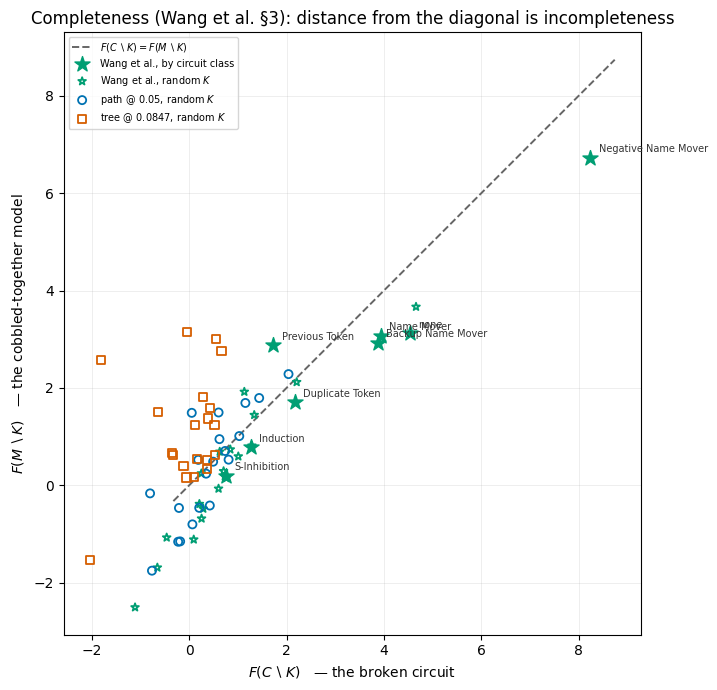

In [16]:
# Wang et al.'s completeness scatter: a complete circuit sits on F(C\K) = F(M\K).
fig, ax = plt.subplots(figsize=(7.5, 7))

lo = min(F_EMPTY, float(df_class["F(C\\K)"].min()), float(df_class["F(M\\K)"].min())) - 0.5
hi = max(F_MODEL, float(df_class["F(C\\K)"].max()), float(df_class["F(M\\K)"].max())) + 0.5
ax.plot([lo, hi], [lo, hi], color="#666666", lw=1.4, ls="--",
        label=r"$F(C\setminus K)=F(M\setminus K)$")

# the seven circuit classes, ground truth
ax.scatter(df_class["F(C\\K)"], df_class["F(M\\K)"], s=130, marker="*",
           color=REF_STYLE["ground truth"]["color"], zorder=3,
           label="Wang et al., by circuit class")
for _, r in df_class.iterrows():
    ax.annotate(r["K"], (r["F(C\\K)"], r["F(M\\K)"]), fontsize=7,
                textcoords="offset points", xytext=(6, 4), color="#333333")

# random K, for the ground truth and for the matched-budget circuits
srng = random.Random(CFG.seed)
scatter_specs = (
    ("Wang et al., random $K$", GT_CIRCUIT, REF_STYLE["ground truth"]),
    (f"path @ {T_PATH:.3g}, random $K$", PATH_CIRCUITS[T_PATH], STYLE["path"]),
    (f"tree @ {T_TREE:.3g}, random $K$", TREE_CIRCUITS[T_TREE], STYLE["tree"]),
)
for label, circuit, spec in scatter_specs:
    if not circuit.elements:
        continue
    xs, ys = [], []
    for K in random_subsets(circuit.elements, CFG.n_completeness_samples, srng):
        xs.append(EV.F(circuit.elements - K))
        ys.append(EV.F_model_minus(K))
    ax.scatter(xs, ys, s=34, marker=spec["marker"], facecolors="none", linewidths=1.3,
               edgecolors=spec["color"], label=label, zorder=2)

ax.set_xlabel(r"$F(C\setminus K)$   — the broken circuit")
ax.set_ylabel(r"$F(M\setminus K)$   — the cobbled-together model")
ax.set_title("Completeness (Wang et al. §3): distance from the diagonal is incompleteness")
ax.set_aspect("equal", adjustable="box")
ax.grid(**GRID)
ax.legend(fontsize=7, loc="upper left")

fig.tight_layout()
out = os.path.join(OUT_DIR, "completeness_scatter_positional.png")
fig.savefig(out, dpi=180, bbox_inches="tight")
print(f"saved {out}")
plt.show()

## 13. What this notebook does and does not claim

**Computed exactly as in Wang et al. (2023).** The circuit is a set of `(head, position)` elements;
MLPs, embeddings, biases and LayerNorms are never ablated; ablation values are the per-position mean
over the ABC counterfactual distribution within one template group; the metric is the IO − S logit
difference at the `end` token; faithfulness is `F(C)` against `F(M)` with no normalisation;
incompleteness is `|F(C\K) − F(M\K)|` in raw units, with `F(M\K)` ablating `K` **only at `K`'s own
positions**; `K` is drawn Bernoulli(½), by circuit class, and by their greedy adversarial search.

**Two known deviations.**

1. **BOS.** They run with `prepend_bos=False`; `ExperimentManager` hardcodes `prepend_bos=True` and
   search and evaluation must agree. `F(M)` and every ablation value therefore sit on a slightly
   different footing than the published numbers, so `F(GT)/F(M)` here need not reproduce their
   figure exactly.
2. **One template layout** rather than mixed templates with per-template ablation groups. Within a
   group the two are the same computation; the cost is template diversity, not correctness.

**Not attempted.** Edge-level knockout — Wang et al. evaluate at head level and there is no
counterpart to compare against. At node level a path set and a tree collapse onto the same object
whenever they touch the same `(head, position)` pairs, so the positional resolution here recovers
part, but not all, of what v1's edge table was measuring.

**Carried but unused.** The MLPs both searches discover, in `discovered_mlps_v2.csv`.